# EduTrack Analytics - Analyse Exploratoire des Donnees (EDA)

Ce notebook explore les donnees academiques synthetiques: nettoyage, statistiques
descriptives, distributions, correlations et segmentation des etudiants par niveau.

Les fichiers sont generes par `data/generate_synthetic.py` et lus depuis `../data/samples/`.
Les colonnes sont en francais.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
SAMPLES = '../data/samples'

## 1. Chargement des donnees

In [2]:
etudiants = pd.read_csv(f'{SAMPLES}/etudiants.csv')
notes = pd.read_csv(f'{SAMPLES}/notes.csv')
absences = pd.read_excel(f'{SAMPLES}/absences.xlsx')
print('etudiants:', etudiants.shape, '| notes:', notes.shape, '| absences:', absences.shape)
etudiants.head()

etudiants: (125, 7) | notes: (2000, 7) | absences: (447, 6)


,code_etudiant,prenom,nom,courriel,classe,niveau,annee
0,STU0001,Sara,Berrada,sara.berrada1@edu.ma,B1-INFO,Bachelor 1,2025-2026
1,STU0002,Anas,Lahlou,anas.lahlou2@edu.ma,B1-INFO,Bachelor 1,2025-2026
2,STU0003,Lina,Benali,lina.benali3@edu.ma,B1-INFO,Bachelor 1,2025-2026
3,STU0004,Hajar,Berrada,hajar.berrada4@edu.ma,B1-INFO,Bachelor 1,2025-2026
4,STU0005,Reda,Benali,reda.benali5@edu.ma,B1-INFO,Bachelor 1,2025-2026


## 2. Nettoyage
Suppression des doublons et controle des valeurs (notes 0..20, dates, champs manquants).

In [3]:
# Doublons
print('Doublons notes:', notes.duplicated().sum())
notes = notes.drop_duplicates()

# Notes hors intervalle 0..20
hors_bornes = ~notes['note'].between(0, 20)
print('Notes hors 0..20:', hors_bornes.sum())
notes = notes[~hors_bornes]

# Dates d'absence invalides
absences['date'] = pd.to_datetime(absences['date'], errors='coerce')
print('Dates invalides:', absences['date'].isna().sum())

# Valeurs manquantes etudiants
print('Noms manquants:', etudiants['nom'].isna().sum())
etudiants = etudiants.dropna(subset=['nom'])
etudiants.shape, notes.shape, absences.shape

Doublons notes: 0
Notes hors 0..20: 0
Dates invalides: 0
Noms manquants: 0


((125, 7), (2000, 7), (447, 6))

## 3. Statistiques descriptives par module

In [4]:
par_module = notes.groupby('nom_module')['note'].agg(
    moyenne='mean', mediane='median', min='min', max='max', variance='var', ecart_type='std'
).round(2).sort_values('moyenne')
par_module['taux_reussite'] = (
    notes.assign(ok=notes['note'] >= 10).groupby('nom_module')['ok'].mean().round(3)
)
par_module

,moyenne,mediane,min,max,variance,ecart_type,taux_reussite
nom_module,,,,,,,
Communication,11.08,10.86,2.46,20.0,11.63,3.41,0.592
Algorithmique,11.09,10.96,2.43,20.0,12.72,3.57,0.620
Mathematiques,11.15,11.30,1.50,20.0,12.05,3.47,0.660
Anglais,11.22,11.30,2.11,20.0,13.14,3.63,0.640
Statistiques,11.23,11.33,1.12,20.0,13.58,3.68,0.624
Machine Learning,11.25,11.20,2.85,20.0,13.20,3.63,0.640
Developpement Web,11.27,11.26,1.33,20.0,12.43,3.53,0.644
Bases de donnees,11.29,11.31,2.72,20.0,11.21,3.35,0.648


## 4. Statistiques descriptives par classe


In [5]:
notes_cls = notes.merge(etudiants[['code_etudiant', 'classe']], on='code_etudiant', how='left')
par_classe = notes_cls.groupby('classe')['note'].agg(
    moyenne='mean', mediane='median', ecart_type='std', n_notes='count'
).round(2).sort_values('moyenne', ascending=False)
par_classe['taux_reussite'] = (
    notes_cls.assign(ok=notes_cls['note'] >= 10).groupby('classe')['ok'].mean().round(3)
)
par_classe


,moyenne,mediane,ecart_type,n_notes,taux_reussite
classe,,,,,
B1-INFO,11.42,11.59,3.48,512,0.670
B3-DATA,11.31,10.92,3.74,496,0.595
M1-DATA,11.27,11.42,3.79,496,0.647
B2-INFO,10.78,10.91,3.03,496,0.621


## 5. Distribution des notes

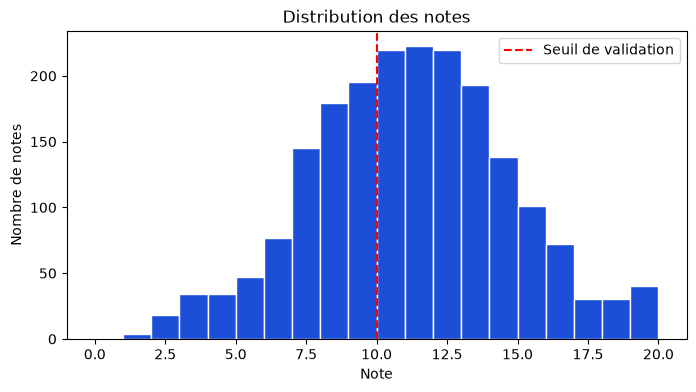

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(notes['note'], bins=range(0, 21), color='#1d4ed8', edgecolor='white')
ax.axvline(10, color='red', linestyle='--', label='Seuil de validation')
ax.set_xlabel('Note'); ax.set_ylabel('Nombre de notes'); ax.set_title('Distribution des notes')
ax.legend(); plt.show()

## 6. Correlation entre absences et resultats

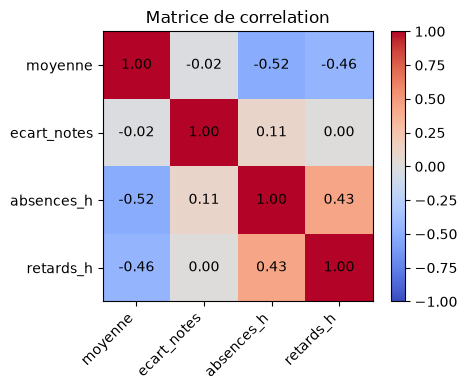

Correlation absences / moyenne: -0.516


In [7]:
moyenne = notes.groupby('code_etudiant')['note'].mean().rename('moyenne')
ecart = notes.groupby('code_etudiant')['note'].std().rename('ecart_notes')
abs_h = absences[absences['type_absence'] == 'absence'].groupby('code_etudiant')['heures'].sum().rename('absences_h')
retards_h = absences[absences['type_absence'] == 'retard'].groupby('code_etudiant')['heures'].sum().rename('retards_h')

feat = pd.concat([moyenne, ecart, abs_h, retards_h], axis=1).fillna(0)
corr = feat.corr()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')
fig.colorbar(im); ax.set_title('Matrice de correlation'); plt.tight_layout(); plt.show()
print('Correlation absences / moyenne:', round(corr.loc['absences_h', 'moyenne'], 3))

## 7. Detection d'anomalies (z-score et IQR)

Notes inhabituelles par rapport a la moyenne de leur module (|z| >= 2.5) et etudiants
dont le total d'heures d'absence depasse le seuil de Tukey (Q3 + 1.5 x IQR).

In [8]:
# Notes inhabituelles : z-score par module (ignore les modules de moins de 3 notes)
rows = []
for mod, g in notes.groupby('nom_module'):
    s = g['note'].std(ddof=1)
    if not s or np.isnan(s) or len(g) < 3:
        continue
    z = (g['note'] - g['note'].mean()) / s
    rows.append(g.assign(z_score=z.round(2))[z.abs() >= 2.5])
notes_z = pd.concat(rows) if rows else notes.assign(z_score=[]).iloc[0:0]
print('Notes inhabituelles (|z| >= 2.5):', len(notes_z))
notes_z[['code_etudiant', 'nom_module', 'note', 'z_score']].head(10)


Notes inhabituelles (|z| >= 2.5): 19


,code_etudiant,nom_module,note,z_score
1085,STU0068,Anglais,2.11,-2.51
1981,STU0124,Anglais,2.13,-2.51
983,STU0062,Bases de donnees,19.97,2.59
1111,STU0070,Bases de donnees,19.92,2.58
1414,STU0089,Bases de donnees,20.00,2.60
1830,STU0115,Bases de donnees,19.87,2.56
1943,STU0122,Bases de donnees,2.72,-2.56
1959,STU0123,Bases de donnees,2.82,-2.53
1310,STU0082,Communication,19.96,2.60
1838,STU0115,Communication,20.00,2.61


In [9]:
# Absences excessives : methode de Tukey (IQR) sur le total d'heures par etudiant
abs_tot = absences.groupby('code_etudiant')['heures'].sum()
q1, q3 = abs_tot.quantile(0.25), abs_tot.quantile(0.75)
seuil = q3 + 1.5 * (q3 - q1)
excessives = abs_tot[abs_tot > seuil].sort_values(ascending=False)
print(f'Seuil IQR : {seuil:.1f} h | etudiants au-dessus : {len(excessives)}')
excessives.head(10)


Seuil IQR : 26.5 h | etudiants au-dessus : 7


code_etudiant
STU0121    62
STU0123    56
STU0124    54
STU0125    46
STU0122    45
STU0103    30
STU0068    29
Name: heures, dtype: int64

## 8. Segmentation des etudiants par niveau
Classement de chaque etudiant en excellent / stable / moyen / fragile / a risque a partir de sa moyenne.

segment
moyen        47
fragile      29
stable       29
a_risque     15
excellent     5
Name: count, dtype: int64


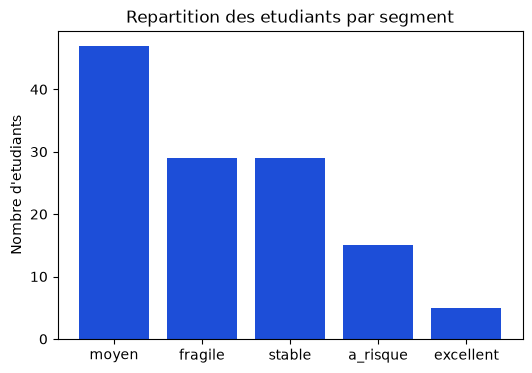

In [10]:
def segment(m):
    if m >= 16: return 'excellent'
    if m >= 13: return 'stable'
    if m >= 10: return 'moyen'
    if m >= 8:  return 'fragile'
    return 'a_risque'

feat['segment'] = feat['moyenne'].apply(segment)
counts = feat['segment'].value_counts()
print(counts)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index, counts.values, color='#1d4ed8')
ax.set_ylabel("Nombre d'etudiants"); ax.set_title('Repartition des etudiants par segment')
plt.show()

## 9. Conclusions

- La distribution des notes est centree autour du seuil de validation, avec une part notable d'etudiants sous la moyenne.
- Les statistiques par module et par classe font ressortir les matieres les plus difficiles et les ecarts entre groupes.
- La correlation negative entre les heures d'absence et la moyenne confirme l'impact de l'assiduite sur la performance.
- La detection d'anomalies (z-score sur les notes, IQR sur les absences) isole les cas individuels a examiner.
- La segmentation par niveau met en evidence les groupes d'etudiants a accompagner en priorite.

Ces analyses sont reprises dans l'application (tableau de bord, alertes, segmentation) et dans le rapport genere automatiquement.